## Logistic Regression

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, ConfusionMatrixDisplay
%pip install imbalanced-learn   
from imblearn.over_sampling import SMOTE,RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler

  Using cached imbalanced_learn-0.14.2-py3-none-any.whl.metadata (8.9 kB)
  Using cached sklearn_compat-0.1.6-py3-none-any.whl.metadata (22 kB)
Using cached imbalanced_learn-0.14.2-py3-none-any.whl (236 kB)
Using cached sklearn_compat-0.1.6-py3-none-any.whl (22 kB)

   ---------------------------------------- 0/2 [sklearn-compat]
   ---------------------------------------- 0/2 [sklearn-compat]
   ---------------------------------------- 0/2 [sklearn-compat]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
  

In [4]:
df = pd.read_csv("C:\\Programming\\Machine Learning\\NTI Project\\Data Sample\\healthcare-dataset-stroke-data.csv")
df.head(20)

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
5,56669,Male,81.0,0,0,Yes,Private,Urban,186.21,29.0,formerly smoked,1
6,53882,Male,74.0,1,1,Yes,Private,Rural,70.09,27.4,never smoked,1
7,10434,Female,69.0,0,0,No,Private,Urban,94.39,22.8,never smoked,1
8,27419,Female,59.0,0,0,Yes,Private,Rural,76.15,NaN,Unknown,1
9,60491,Female,78.0,0,0,Yes,Private,Urban,58.57,24.2,Unknown,1


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [6]:
df.shape

(5110, 12)

In [7]:
df.isnull().sum()

id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,5110.0,36517.829354,21161.721625,67.00,17741.250,36932.000,54682.00,72940.00
age,5110.0,43.226614,22.612647,0.08,25.000,45.000,61.00,82.00
hypertension,5110.0,0.097456,0.296607,0.00,0.000,0.000,0.00,1.00
heart_disease,5110.0,0.054012,0.226063,0.00,0.000,0.000,0.00,1.00
avg_glucose_level,5110.0,106.147677,45.283560,55.12,77.245,91.885,114.09,271.74
bmi,4909.0,28.893237,7.854067,10.30,23.500,28.100,33.10,97.60
stroke,5110.0,0.048728,0.215320,0.00,0.000,0.000,0.00,1.00


<Axes: >

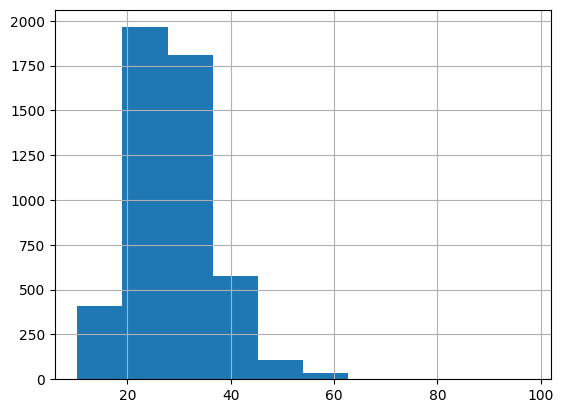

In [9]:
df["bmi"].hist()

In [10]:
df["bmi"] = df["bmi"].fillna(df["bmi"].mean())

In [11]:
df.isnull().sum()

id                   0
gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64

In [12]:
le = LabelEncoder()
for col in ["gender", "ever_married", "work_type", "Residence_type", "smoking_status"]:
    df[col] = le.fit_transform(df[col])
df.head(20)

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,1,67.0,0,1,1,2,1,228.69,36.600000,1,1
1,51676,0,61.0,0,0,1,3,0,202.21,28.893237,2,1
2,31112,1,80.0,0,1,1,2,0,105.92,32.500000,2,1
3,60182,0,49.0,0,0,1,2,1,171.23,34.400000,3,1
4,1665,0,79.0,1,0,1,3,0,174.12,24.000000,2,1
5,56669,1,81.0,0,0,1,2,1,186.21,29.000000,1,1
6,53882,1,74.0,1,1,1,2,0,70.09,27.400000,2,1
7,10434,0,69.0,0,0,0,2,1,94.39,22.800000,2,1
8,27419,0,59.0,0,0,1,2,0,76.15,28.893237,0,1
9,60491,0,78.0,0,0,1,2,1,58.57,24.200000,0,1


In [13]:
x = df.drop(columns=["id", "work_type", "gender", "Residence_type", "stroke"])
y = df["stroke"]

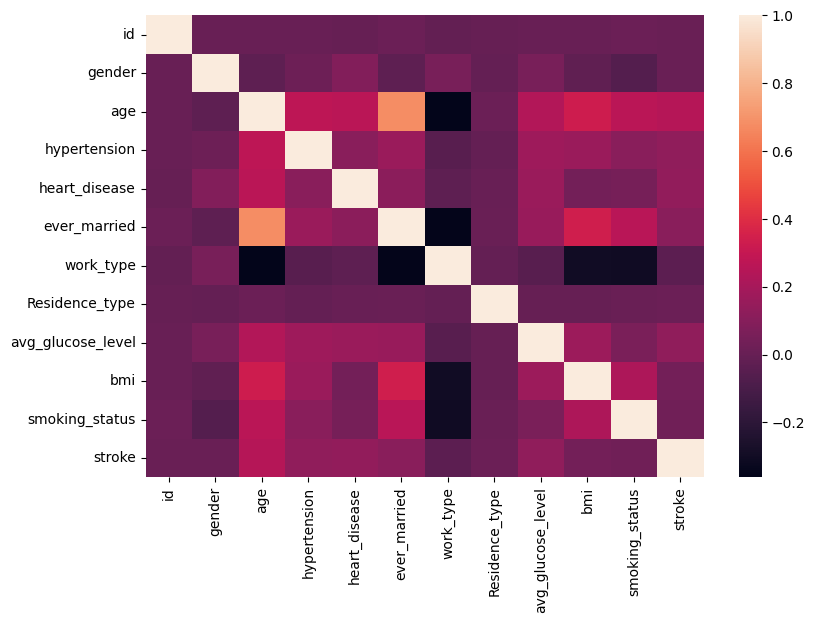

In [14]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(9,6))
sns.heatmap(corr)
plt.show()

In [15]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [16]:
rus = SMOTE(random_state=42)
x_train,y_train = rus.fit_resample(x_train,y_train)

In [17]:
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [18]:
model = LogisticRegression()
model.fit(x_train, y_train)
y_pred = model.predict(x_test)

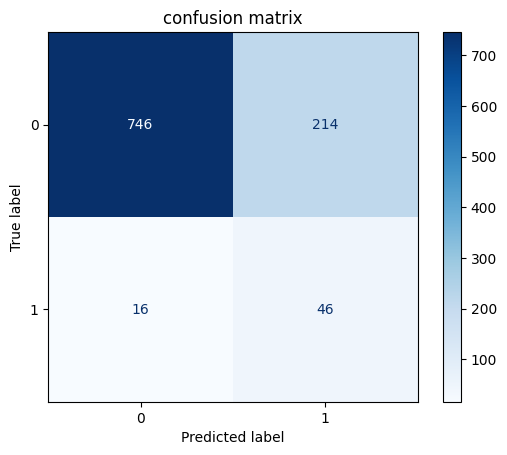

In [19]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("confusion matrix")
plt.show()

In [20]:
print("cm: ", confusion_matrix(y_test, y_pred))
print("ROC-AUC Score: ", roc_auc_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

cm:  [[746 214]
 [ 16  46]]
ROC-AUC Score:  0.7595094086021505
              precision    recall  f1-score   support

           0       0.98      0.78      0.87       960
           1       0.18      0.74      0.29        62

    accuracy                           0.77      1022
   macro avg       0.58      0.76      0.58      1022
weighted avg       0.93      0.77      0.83      1022



## KNN

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, ConfusionMatrixDisplay
from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler

In [22]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [23]:
rus = RandomUnderSampler(random_state=42)
x_train,y_train = rus.fit_resample(x_train,y_train)

In [24]:
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [25]:
for k in range(1, 21):
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(x_train, y_train)

    y_pred = model.predict(x_test)

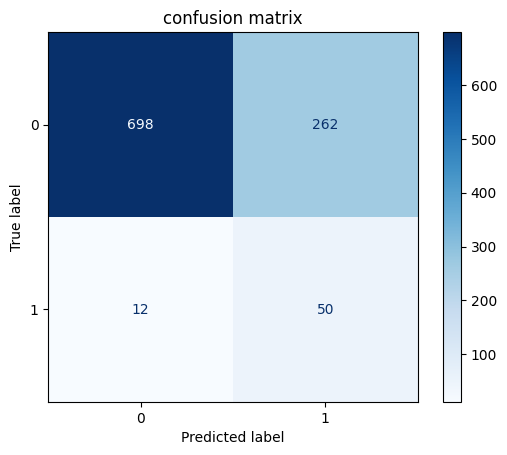

In [26]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("confusion matrix")
plt.show()

In [27]:
print("cm: ", confusion_matrix(y_test, y_pred))
print("ROC-AUC Score: ", roc_auc_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

cm:  [[698 262]
 [ 12  50]]
ROC-AUC Score:  0.7667674731182794
              precision    recall  f1-score   support

           0       0.98      0.73      0.84       960
           1       0.16      0.81      0.27        62

    accuracy                           0.73      1022
   macro avg       0.57      0.77      0.55      1022
weighted avg       0.93      0.73      0.80      1022



## SVM

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score,ConfusionMatrixDisplay
from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler

In [29]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [30]:
rus = SMOTE(random_state=42)
x_train,y_train = rus.fit_resample(x_train,y_train)

In [31]:
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [32]:
model = SVC(C=0.1)
model.fit(x_train, y_train)
y_pred = model.predict(x_test)

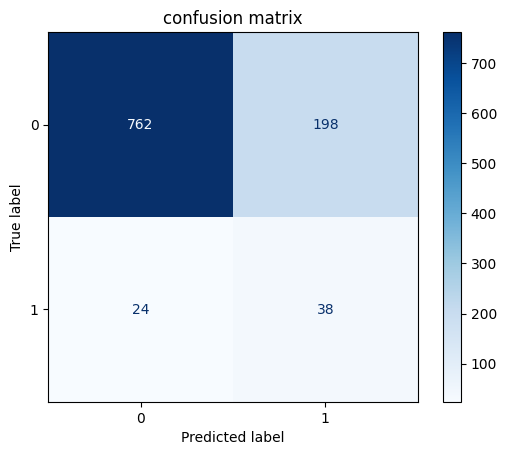

In [33]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("confusion matrix")
plt.show()

In [34]:
print("cm: ", confusion_matrix(y_test, y_pred))
print("ROC-AUC Score: ", roc_auc_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

cm:  [[762 198]
 [ 24  38]]
ROC-AUC Score:  0.7033266129032257
              precision    recall  f1-score   support

           0       0.97      0.79      0.87       960
           1       0.16      0.61      0.26        62

    accuracy                           0.78      1022
   macro avg       0.57      0.70      0.56      1022
weighted avg       0.92      0.78      0.84      1022



## Random forest

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, ConfusionMatrixDisplay
from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler

In [36]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [37]:
rus = RandomUnderSampler(random_state=42)
x_train,y_train = rus.fit_resample(x_train,y_train)

In [38]:
model = RandomForestClassifier(n_estimators=100, class_weight="balanced_subsample", random_state=42)
model.fit(x_train, y_train)
y_pred = model.predict(x_test)

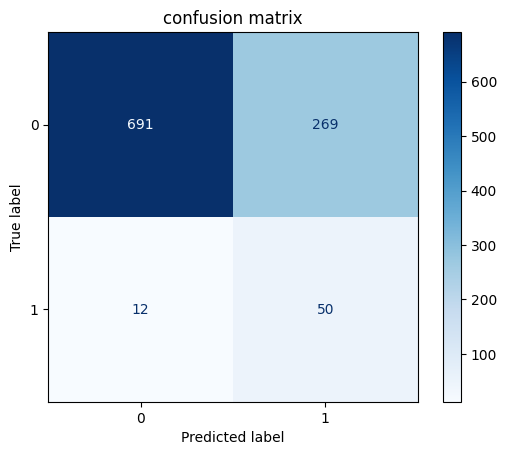

In [39]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("confusion matrix")
plt.show()

In [40]:
print("cm: ", cm)
print("ROC-AUC Score: ", roc_auc_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

cm:  [[691 269]
 [ 12  50]]
ROC-AUC Score:  0.7631216397849461
              precision    recall  f1-score   support

           0       0.98      0.72      0.83       960
           1       0.16      0.81      0.26        62

    accuracy                           0.73      1022
   macro avg       0.57      0.76      0.55      1022
weighted avg       0.93      0.73      0.80      1022

